<a href="https://colab.research.google.com/github/TayBrig-Data/data101-final-project/blob/main/Data_Science_Project_Visualize_and_Explore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Code to find how many medium and high important events happened each year from 2020-2024

In [8]:
# Filter for medium and high importance
importance_levels = ['medium', 'high']
df_importance = df_clean[df_clean['importance'].isin(importance_levels)]

# Group by Year and Importance
# We use the previously identified date_col
events_by_importance = df_importance.groupby([df_importance[date_col].dt.year, 'importance']).size().unstack(fill_value=0)

# Display the data
print("Events by Importance per Year:")
display(events_by_importance)

Events by Importance per Year:


importance,high,medium
date,,
2020,566,2206
2021,559,2018
2022,573,2235
2023,577,2596
2024,579,2516


Code used to find how many events happened and show them in a histogram separated by their level of importance

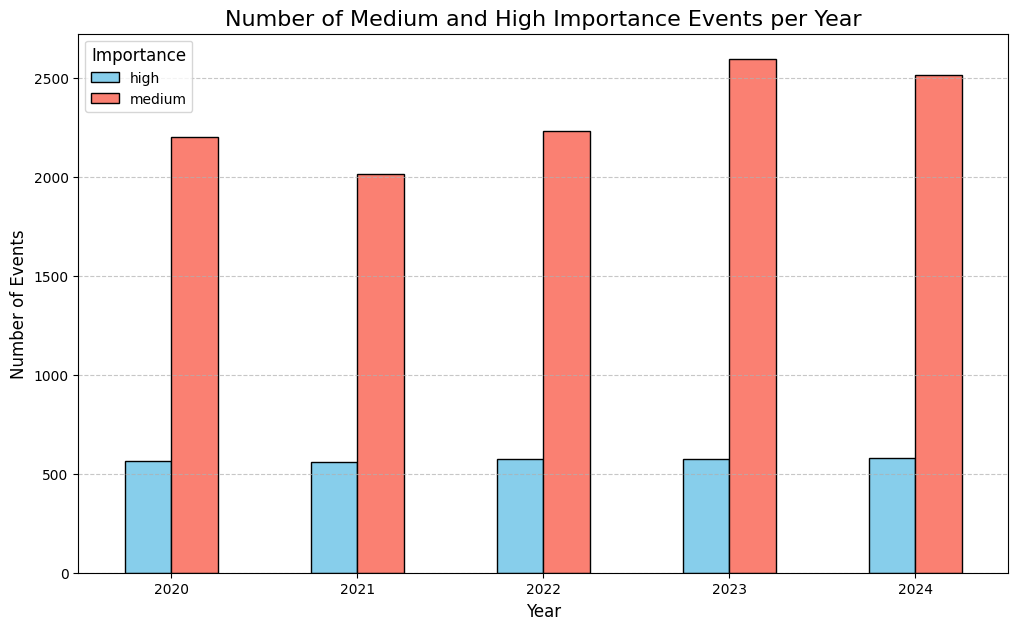

In [9]:
# Plotting the grouped data
events_by_importance.plot(kind='bar', figsize=(12, 7), color=['skyblue', 'salmon'], edgecolor='black')

plt.title('Number of Medium and High Importance Events per Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Events', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Importance', title_fontsize='12')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Code used to make a histogram showing the total amount of events with no regard to level of importance

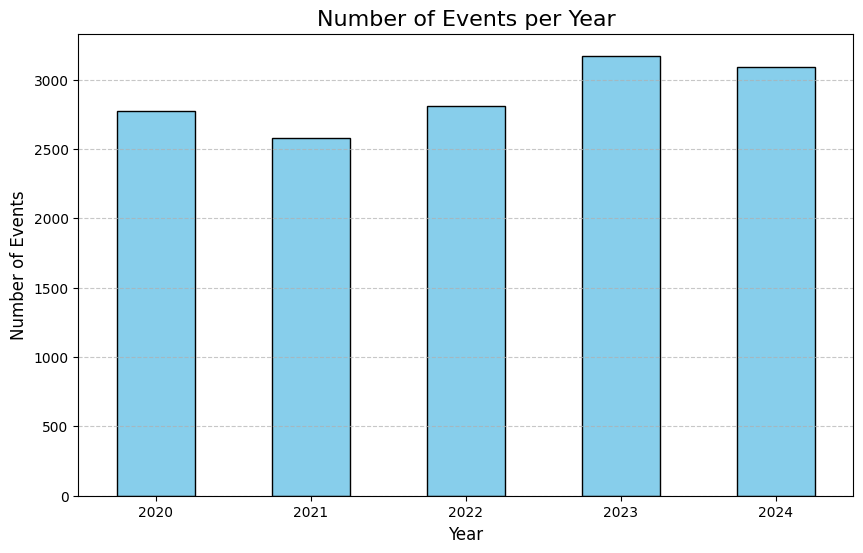

In [10]:
import matplotlib.pyplot as plt

# Plotting the data
plt.figure(figsize=(10, 6))
# Since events_per_year is a Series with Year as index, we can plot it directly
events_per_year.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Events per Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Events', fontsize=12)
plt.xticks(rotation=0)  # Keep year labels horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [4]:
import pandas as pd

# Load the dataframe
df = pd.read_csv('/content/Calender_data_cleaned.csv')

# Display the first few rows to understand the structure, especially date columns
display(df.head())

,id,date,zone,currency,importance,event,actual
0,399118,2020-01-02,united states,USD,medium,Continuing Jobless Claims,"1,728K"
1,399117,2020-01-02,united states,USD,high,Initial Jobless Claims,222K
2,399269,2020-01-03,united kingdom,GBP,medium,Nationwide HPI (MoM) (Dec),0.1%
3,399272,2020-01-03,united kingdom,GBP,medium,Nationwide HPI (YoY) (Dec),1.4%
4,398410,2020-01-03,türkiye,TRY,medium,CPI (MoM) (Dec),0.74%


In [5]:
# Assuming there is a column representing the date.
# I'll look for common date column names or the first column if not obvious.
# Based on the filename, it's likely 'Date', 'Start Date', or similar.
# Let's inspect columns first.
print(df.columns)

Index(['id', 'date', 'zone', 'currency', 'importance', 'event', 'actual'], dtype='object')


In [6]:
# Once we identify the date column (let's assume 'Start Date' or 'Date' based on typical calendar data)
# I'll write code that tries to find it dynamically or uses a likely candidate.

# Attempt to identify the date column
date_col = None
for col in df.columns:
    if 'date' in col.lower():
        date_col = col
        break

if date_col:
    print(f"Using column '{date_col}' for date information.")
    # Convert to datetime, coercing errors to NaT
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

    # Drop rows with invalid dates
    df_clean = df.dropna(subset=[date_col])

    # Extract year
    events_per_year = df_clean[date_col].dt.year.value_counts().sort_index()

    # Display the result
    print("\nNumber of events per year:")
    display(events_per_year)
else:
    print("Could not automatically detect a date column. Please specify the column name.")

Using column 'date' for date information.

Number of events per year:


,count
date,
2020,2772
2021,2577
2022,2808
2023,3173
2024,3095


Make line chart to help visualize the value increase of NVidia stock

In [11]:
# Load the NVidia stock data
df_nvidia = pd.read_csv('/content/NVidia_stock_history_formatted.csv')

# Display the first few rows to check column names
display(df_nvidia.head())

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,01/02/2020,5.944750,5.973633,5.894204,5.973633,237536000,0.0,0.0
1,01/03/2020,5.853867,5.921843,5.828967,5.878019,205384000,0.0,0.0
2,01/06/2020,5.784646,5.907898,5.758502,5.902669,262636000,0.0,0.0
3,01/07/2020,5.931056,6.019947,5.885988,5.974132,314856000,0.0,0.0
4,01/08/2020,5.969898,6.026669,5.929810,5.985336,277108000,0.0,0.0


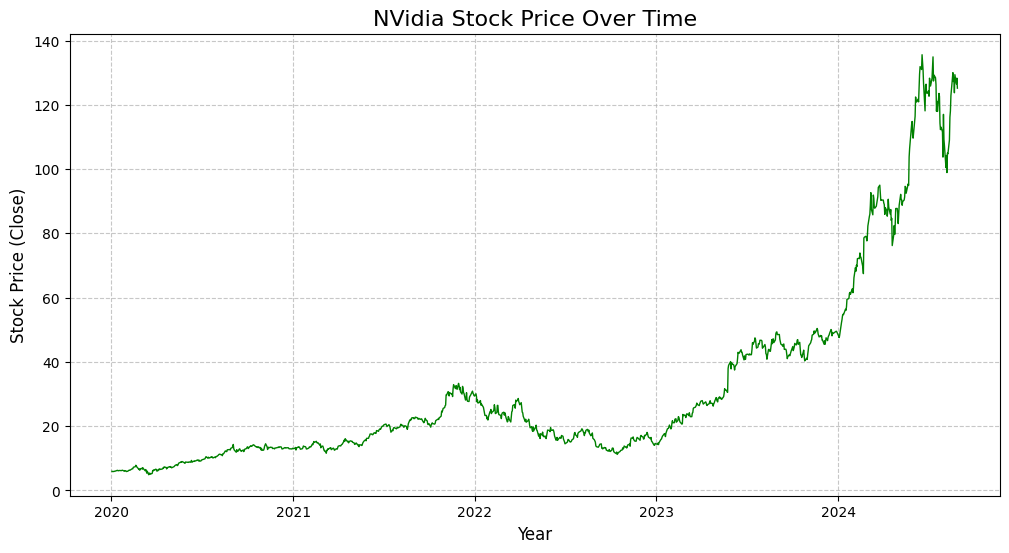

In [12]:
# Attempt to identify date and price columns dynamically
date_col_nv = None
price_col_nv = None

# Find date column
for col in df_nvidia.columns:
    if 'date' in col.lower():
        date_col_nv = col
        break

# Find price column (looking for 'Close' or similar)
possible_price_cols = ['Close', 'Adj Close', 'Price', 'Open']
for candidate in possible_price_cols:
    if candidate in df_nvidia.columns:
        price_col_nv = candidate
        break

if date_col_nv and price_col_nv:
    # Convert date column to datetime
    df_nvidia[date_col_nv] = pd.to_datetime(df_nvidia[date_col_nv])

    # Sort by date to ensure the line chart is drawn correctly
    df_nvidia = df_nvidia.sort_values(date_col_nv)

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(df_nvidia[date_col_nv], df_nvidia[price_col_nv], color='green', linewidth=1)

    plt.title('NVidia Stock Price Over Time', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel(f'Stock Price ({price_col_nv})', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.show()
else:
    print("Could not automatically detect date or price columns. Please check the dataframe head above.")

Bar chart to show the difference of the stock price at the beginning of the year compared to the end

Yearly Price Difference:


,first,last,difference
year,,,
2020,5.973633,13.023961,7.050328
2021,13.082322,29.366701,16.284379
2022,30.075634,14.605634,-15.470000
2023,14.306805,49.515610,35.208805
2024,48.161785,125.175003,77.013218


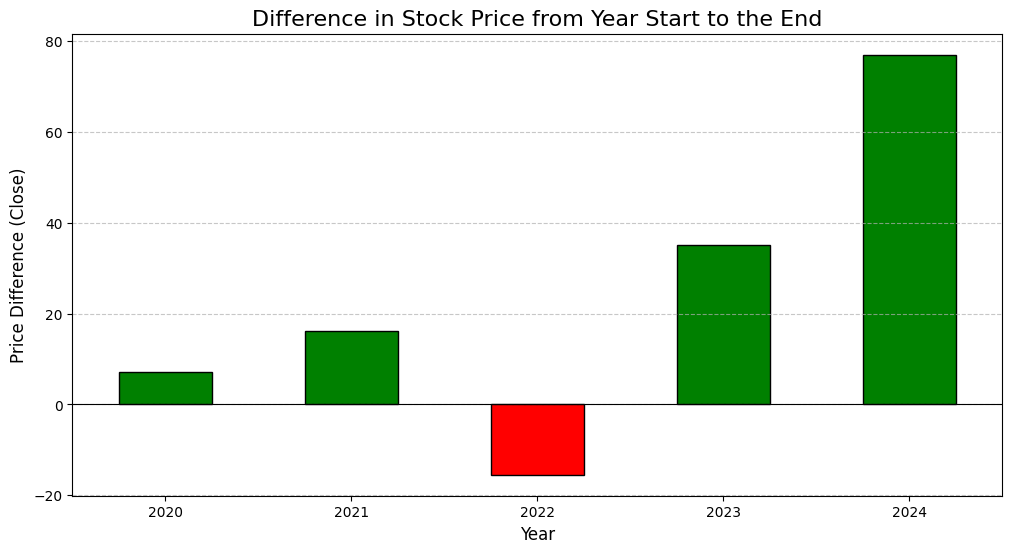

In [14]:
# Calculate the yearly difference
# Ensure the data is sorted by date
df_nvidia = df_nvidia.sort_values(date_col_nv)

# Create a 'year' column if it doesn't exist
df_nvidia['year'] = df_nvidia[date_col_nv].dt.year

# Group by year and get the first and last 'Close' price of each year
yearly_prices = df_nvidia.groupby('year')[price_col_nv].agg(['first', 'last'])

# Calculate the difference (Last Price - First Price)
yearly_prices['difference'] = yearly_prices['last'] - yearly_prices['first']

# Display the calculated data
print("Yearly Price Difference:")
display(yearly_prices)

# Plotting
plt.figure(figsize=(12, 6))

# Color bars: Green for positive difference, Red for negative
colors = yearly_prices['difference'].apply(lambda x: 'green' if x >= 0 else 'red')

yearly_prices['difference'].plot(kind='bar', color=colors, edgecolor='black')

plt.title('Difference in Stock Price from Year Start to the End', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel(f'Price Difference ({price_col_nv})', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a horizontal line at 0 for reference
plt.axhline(0, color='black', linewidth=0.8)

plt.show()

Heatmap to show the potential correlation between the stock price changing and the amount of events that take place. Code combines parts of both data sets to find the potential correlation of event per year and yearly price differences to the make a heatmap

In [15]:
# Combine events_per_year and the 'difference' column from yearly_prices
# Both share the same index (Year)
df_correlation = pd.DataFrame({
    'Annual Events': events_per_year,
    'Price Change': yearly_prices['difference']
})

# Drop any rows where data might be missing (though indices should match)
df_correlation = df_correlation.dropna()

print("Combined Data for Correlation:")
display(df_correlation.head())

Combined Data for Correlation:


,Annual Events,Price Change
2020,2772,7.050328
2021,2577,16.284379
2022,2808,-15.470000
2023,3173,35.208805
2024,3095,77.013218


Correlation Matrix:


,Annual Events,Price Change
Annual Events,1.000000,0.635605
Price Change,0.635605,1.000000


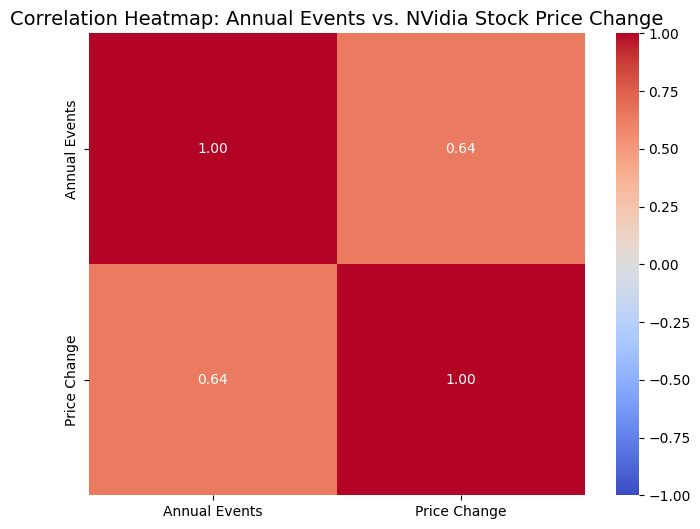

In [16]:
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df_correlation.corr()

# Display the correlation matrix
print("Correlation Matrix:")
display(correlation_matrix)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Heatmap: Annual Events vs. NVidia Stock Price Change', fontsize=14)
plt.show()

With a correlation of 0.64 it shows that there is moderate correltion between the price changes and the amount of annual events